In [13]:
# 1: Imports and Environment Setup
import joblib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
from xgboost import XGBClassifier, plot_importance
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, precision_recall_curve, f1_score
)
from sklearn.model_selection import train_test_split
from pathlib import Path

In [14]:
# 2: Load Preprocessed Artifacts
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "training" / "processed_dataset"

print("Loading preprocessed sparse matrices...")
X_train = sparse.load_npz(DATA_DIR / "X_train.npz")
X_test = sparse.load_npz(DATA_DIR / "X_test.npz")
y_train = np.load(DATA_DIR / "y_train.npy")
y_test = np.load(DATA_DIR / "y_test.npy")

with open(DATA_DIR / "feature_names.json", "r") as f:
    feature_names = json.load(f)

Loading preprocessed sparse matrices...


In [15]:
# 3: Advanced XGBoost Configuration
# Calculate scale_pos_weight: ratio of negative to positive samples
neg_count = np.sum(y_train == 0)
pos_count = np.sum(y_train == 1)
spw = neg_count / pos_count

print(f"Dataset Stats: Normal={neg_count}, Attack={pos_count}")
print(f"Optimal scale_pos_weight: {spw:.4f}")

# IMPORTANT: keep the test set untouched.
# Create a validation split from the training data for early stopping.
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.10,
    random_state=42,
    stratify=y_train,
)
print(f"Train/Val shapes: {X_tr.shape} / {X_val.shape}")

Dataset Stats: Normal=1775011, Attack=257026
Optimal scale_pos_weight: 6.9060
Train/Val shapes: (1828833, 204) / (203204, 204)


In [16]:
# 4: Model Training with Early Stopping
# Using 'hist' for massive datasets to speed up computation
model = XGBClassifier(
    n_estimators=1000,          # High limit, relies on early stopping
    max_depth=6,                # Standard for IDS tasks
    learning_rate=0.05,         # Lower rate for better generalization
    subsample=0.8,              # Prevent overfitting
    colsample_bytree=0.8,       # Prevent overfitting
    scale_pos_weight=spw,       # Handle class imbalance
    tree_method='hist',         # High performance for sparse data
    random_state=42,
    early_stopping_rounds=50,   # Stops if no improvement on validation set
    eval_metric=['logloss', 'aucpr']
)

In [17]:
# Training with a validation split (10% of training data)
# NOTE: we use a validation split from the training set for early stopping.
# The test set (X_test/y_test) is reserved for final evaluation only.
print("Training started...")
model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=True
)

Training started...
[0]	validation_0-logloss:0.64550	validation_0-aucpr:0.99711
[1]	validation_0-logloss:0.60242	validation_0-aucpr:0.99722
[2]	validation_0-logloss:0.56330	validation_0-aucpr:0.99743
[3]	validation_0-logloss:0.52758	validation_0-aucpr:0.99745
[4]	validation_0-logloss:0.49488	validation_0-aucpr:0.99753
[5]	validation_0-logloss:0.46483	validation_0-aucpr:0.99755
[6]	validation_0-logloss:0.43730	validation_0-aucpr:0.99755
[7]	validation_0-logloss:0.41174	validation_0-aucpr:0.99757
[8]	validation_0-logloss:0.38809	validation_0-aucpr:0.99758
[9]	validation_0-logloss:0.36618	validation_0-aucpr:0.99759
[10]	validation_0-logloss:0.34582	validation_0-aucpr:0.99760
[11]	validation_0-logloss:0.32689	validation_0-aucpr:0.99761
[12]	validation_0-logloss:0.30924	validation_0-aucpr:0.99761
[13]	validation_0-logloss:0.29278	validation_0-aucpr:0.99761
[14]	validation_0-logloss:0.27741	validation_0-aucpr:0.99760
[15]	validation_0-logloss:0.26312	validation_0-aucpr:0.99769
[16]	validatio

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,50
,enable_categorical,False
,eval_metric,"['logloss', 'aucpr']"


In [ ]:
# Cell 5: Comprehensive Evaluation
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("\n" + "="*30)
print("CLASSIFICATION REPORT")
print("="*30)
print(classification_report(y_test, y_pred, target_names=["Normal", "Attack"]))

# ROC AUC is a better measure of overall performance
auc = roc_auc_score(y_test, y_proba)
f1 = f1_score(y_test, y_pred)

print(f"ROC AUC Score: {auc:.4f}")
print(f"F1-Score: {f1:.4f}")


CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99    443753
      Attack       0.94      1.00      0.97     64257

    accuracy                           0.99    508010
   macro avg       0.97      0.99      0.98    508010
weighted avg       0.99      0.99      0.99    508010

ROC AUC Score: 0.9998
F1-Score: 0.9663


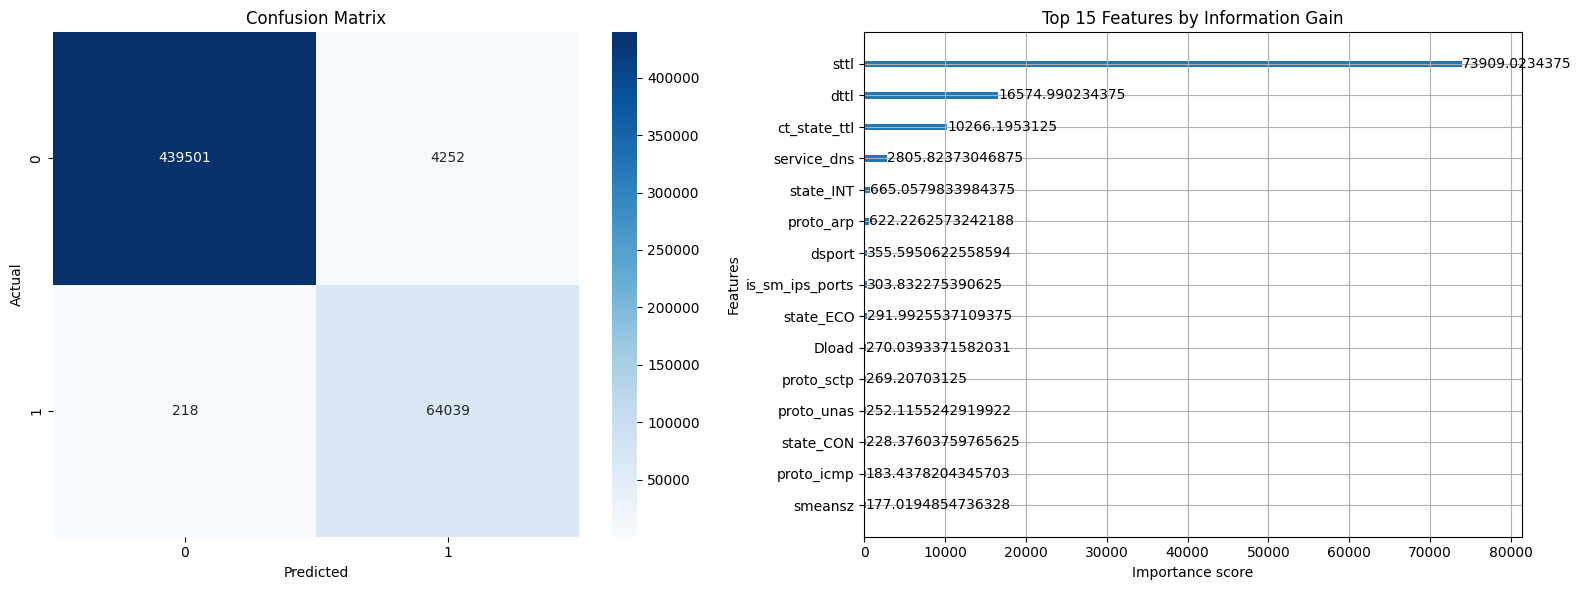

In [19]:
# Cell 6: Visualizing Results
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title("Confusion Matrix")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("Actual")

# Feature Importance (Top 15)
# Map internal XGBoost features back to original names
model.get_booster().feature_names = feature_names
plot_importance(model, max_num_features=15, ax=ax[1], importance_type='gain')
ax[1].set_title("Top 15 Features by Information Gain")

plt.tight_layout()
plt.show()

In [20]:
# Cell 7: Export Model
model.save_model(DATA_DIR / "optimized_xgb_model.json")
print(f"Model saved to {DATA_DIR / 'optimized_xgb_model.json'}")

Model saved to c:\Users\rhmar\GitHub\CTD-Project\training\processed_dataset\optimized_xgb_model.json


In [21]:
import numpy as np
import xgboost as xgb
from scipy import sparse
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Load preprocessed test data
X_test = sparse.load_npz(DATA_DIR / "X_test.npz")
y_test = np.load(DATA_DIR / "y_test.npy")

# Load your trained model
model = xgb.XGBClassifier()
model.load_model(DATA_DIR / "optimized_xgb_model.json")

# Generate predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Print performance results
print("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=["Normal", "Attack"]))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

--- Classification Report ---
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99    443753
      Attack       0.94      1.00      0.97     64257

    accuracy                           0.99    508010
   macro avg       0.97      0.99      0.98    508010
weighted avg       0.99      0.99      0.99    508010

ROC AUC Score: 0.9998
